Device: cuda
Batch shapes -> xin: (64, 4, 128, 128)  y: (64, 128, 128)


c:\Users\asojitra\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\functional.py:402: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return _VF.einsum(equation, operands)  # type: ignore[attr-defined]


Fwd pass ok.
=== Training (MSE + physics + IC + BC) ===


c:\Users\asojitra\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 001 | train_tot=3.011e+00 (data=1.297e-01, phys=2.504e+00, ic=3.721e-01, bc=4.788e-03) | val_mse=7.613e-02 | val_relL2=5.108e-01 | lr=2.0e-03
Epoch 002 | train_tot=9.205e-01 (data=8.732e-02, phys=4.355e-01, ic=3.904e-01, bc=7.277e-03) | val_mse=6.233e-02 | val_relL2=4.510e-01 | lr=2.0e-03
Epoch 003 | train_tot=7.668e-01 (data=8.088e-02, phys=3.122e-01, ic=3.662e-01, bc=7.425e-03) | val_mse=5.977e-02 | val_relL2=4.359e-01 | lr=2.0e-03
Epoch 004 | train_tot=7.040e-01 (data=7.698e-02, phys=2.797e-01, ic=3.399e-01, bc=7.472e-03) | val_mse=5.388e-02 | val_relL2=4.116e-01 | lr=2.0e-03
Epoch 005 | train_tot=6.384e-01 (data=6.458e-02, phys=2.917e-01, ic=2.746e-01, bc=7.573e-03) | val_mse=4.494e-02 | val_relL2=3.731e-01 | lr=2.0e-03
Epoch 006 | train_tot=5.844e-01 (data=5.232e-02, phys=3.061e-01, ic=2.183e-01, bc=7.764e-03) | val_mse=4.032e-02 | val_relL2=3.521e-01 | lr=2.0e-03
Epoch 007 | train_tot=5.317e-01 (data=4.485e-02, phys=2.945e-01, ic=1.845e-01, bc=7.835e-03) | val_mse=3.578e-02

C:\Users\asojitra\AppData\Local\Temp\ipykernel_11160\987457613.py:512: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH_MSE, map_location=device)


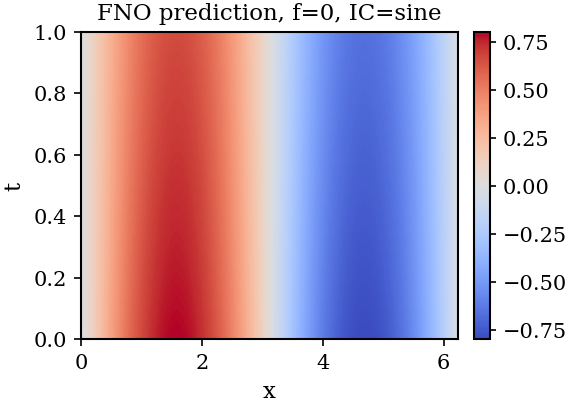

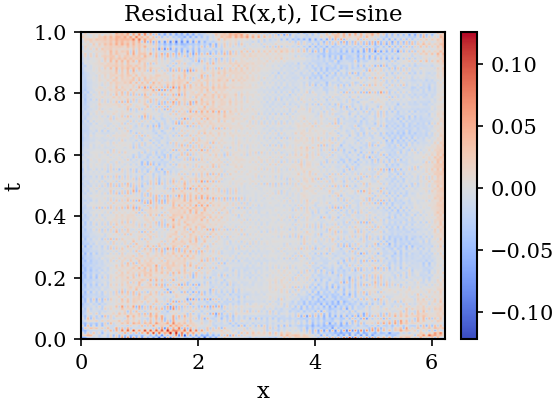

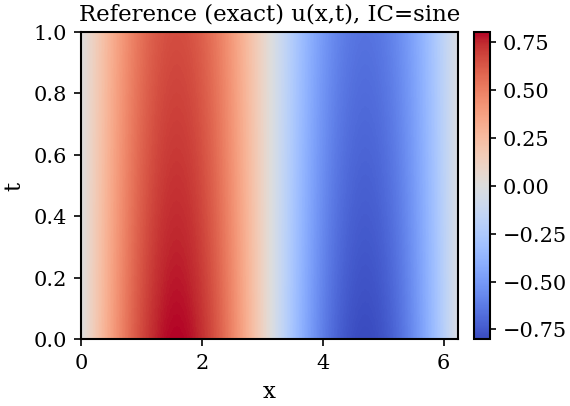

Ref comparison: MSE=1.351e-05 | rel-L2=7.158e-03

=== Inference: f=0, IC='two_mode' ===


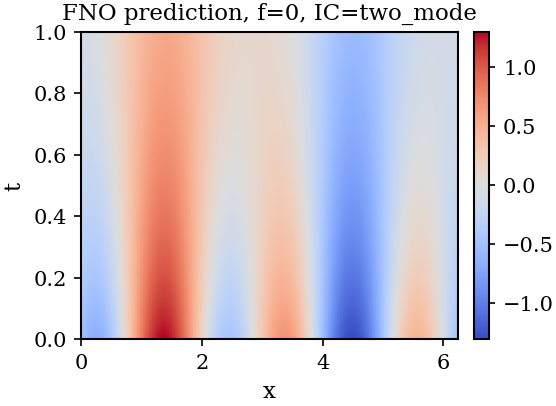

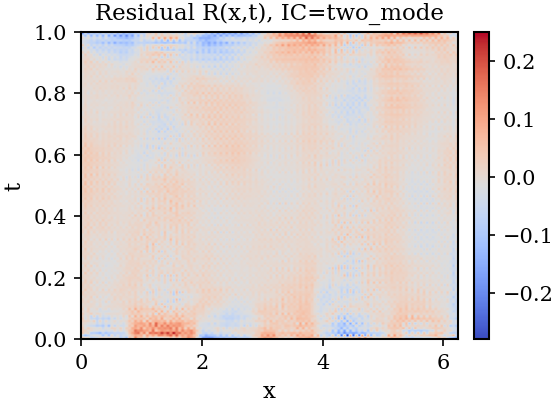

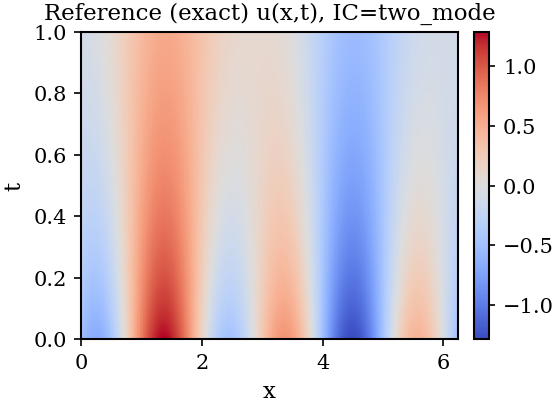

Ref comparison: MSE=1.059e-04 | rel-L2=2.361e-02

=== Inference: f=0, IC='three_mode' ===


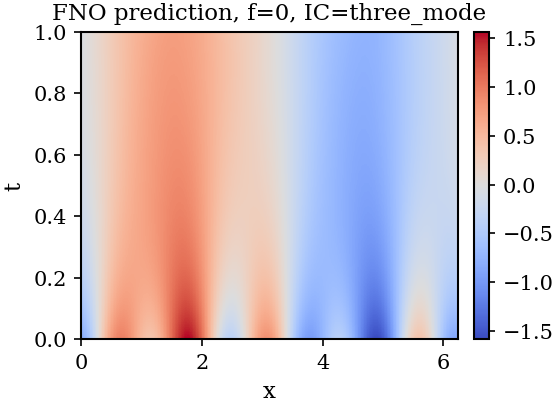

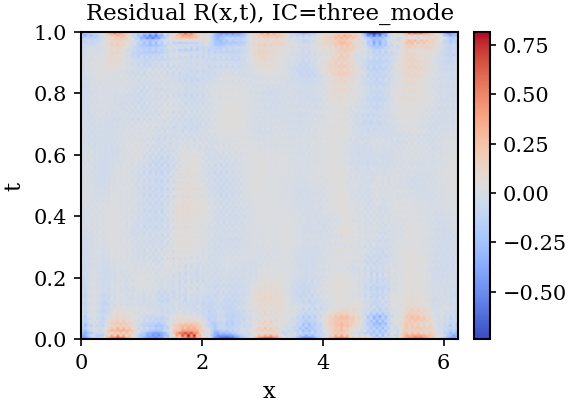

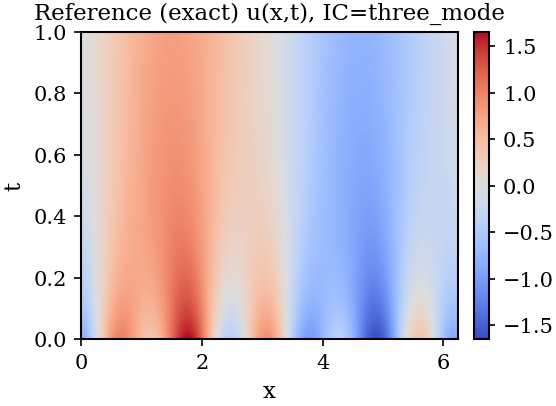

Ref comparison: MSE=5.607e-04 | rel-L2=3.886e-02


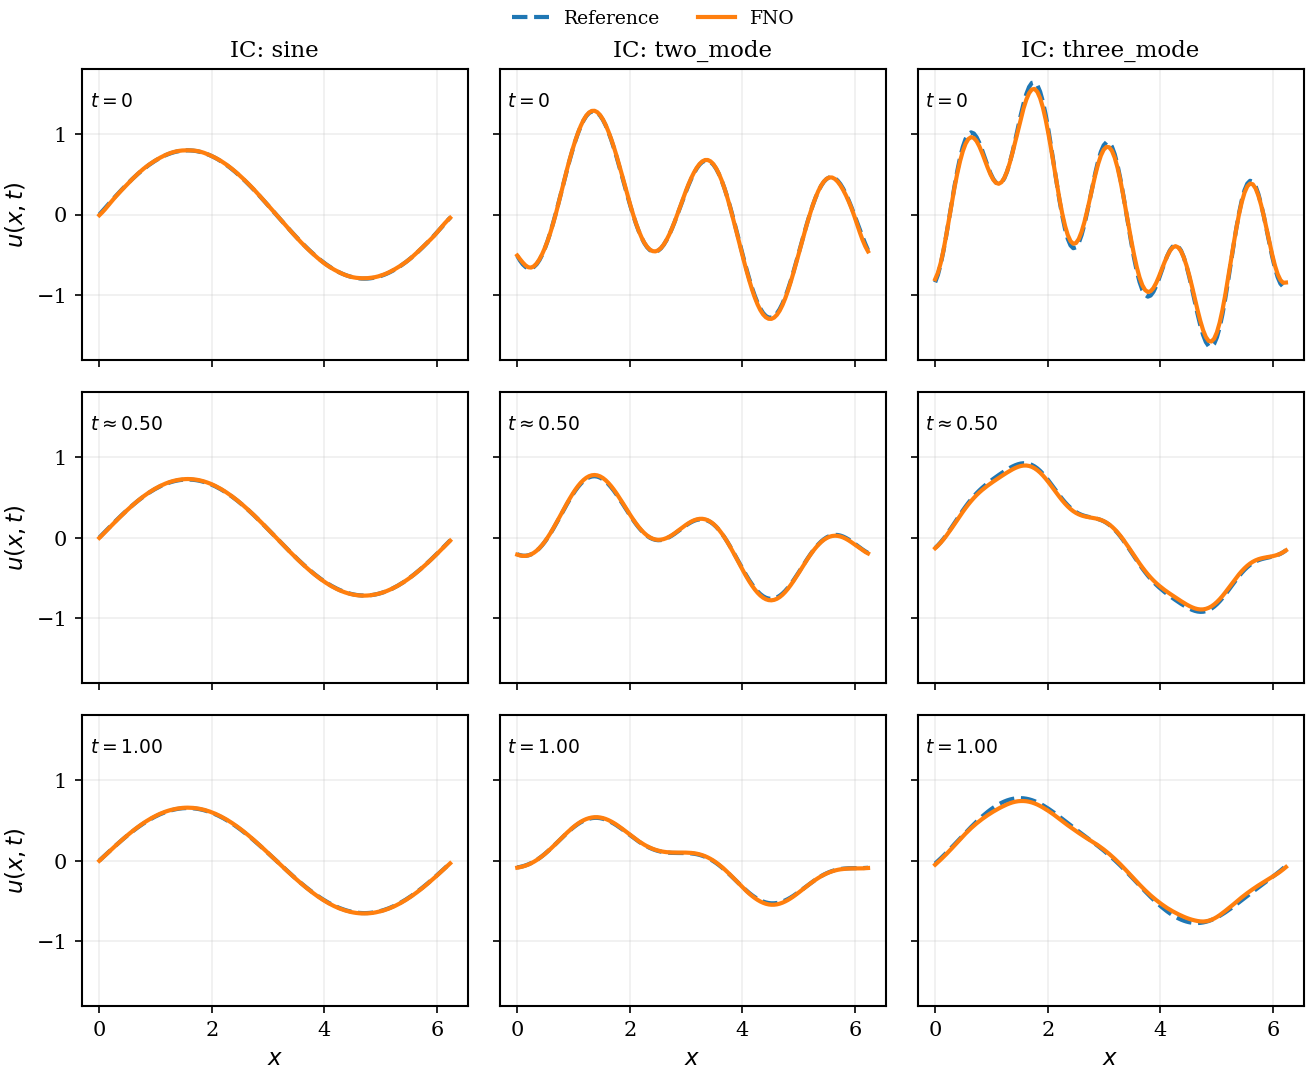

In [97]:
# ============================
# 1D HEAT EQUATION (Periodic x) — FNO2d + Physics-Informed Loss + BC loss
# PDE: u_t - nu u_xx = f
# Inputs: [f, X, T, U0]  -> Output: u(t,x)
# ============================
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import os, random

# ------------------ Matplotlib style (Nature-style-ish) ------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.0,
    "axes.linewidth": 1.0,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

# ------------------ Repro & Device ------------------
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# ------------------ Config ------------------
Nx, Nt   = 128, 128
Lx       = 2*np.pi
Tfinal   = 1.0
nu       = 2e-1

batch_size = 64
train_samples, val_samples = 1024, 32
modes_t, modes_x = 40, 40
width, depth = 64, 4
epochs, lr = 300, 2e-3

# Physics-loss weights
lambda_phys =  1.0      # PDE residual
lambda_ic   =  1.0      # IC consistency at t=0
lambda_bc   =  1.0      # periodic BC consistency in x

CKPT_PATH_MSE  = "fno_heat1d_pinn_best_mse.pt"
CKPT_PATH_RL2  = "fno_heat1d_pinn_best_rl2.pt"

# ------------------ Grids & NumPy Derivatives ------------------
def make_grids(Nx, Nt, Lx, Tfinal):
    x = np.linspace(0, Lx, Nx, endpoint=False)
    t = np.linspace(0, Tfinal, Nt, endpoint=True)
    X, T = np.meshgrid(x, t, indexing='xy')  # (Nt,Nx)
    return x, t, X, T

def kvec(Nx, Lx):
    dx = Lx / Nx
    return 2*np.pi * np.fft.fftfreq(Nx, d=dx)

def dx_spectral(u, kx):
    U  = np.fft.fft(u, axis=1)
    dU = (1j * kx[None,:]) * U
    return np.fft.ifft(dU, axis=1).real

def dxx_spectral(u, kx):
    U   = np.fft.fft(u, axis=1)
    ddU = (-(kx[None,:]**2)) * U
    return np.fft.ifft(ddU, axis=1).real

def dt_finite(u, t):
    Nt = u.shape[0]
    ut = np.zeros_like(u)
    ut[1:-1] = (u[2:] - u[:-2]) / (t[2:,None] - t[:-2,None])
    ut[0]    = (u[1] - u[0])   / (t[1] - t[0])
    ut[-1]   = (u[-1] - u[-2]) / (t[-1] - t[-2])
    return ut

# ------------------ Manufactured fields ------------------
def manufactured_u(X, T, seed=None, Kx=5, Kt=3, kx_max=6, wt_max=6,
                   a_spatial=(0.05, 0.35), a_time=(0.2, 1.0), target_std=0.5):
    """
    u(x,t) = sum_{i=1..Kx} sum_{j=1..Kt} A_i * B_j * sin(k_i x + phi_i) * sin(w_j t + psi_j)
    Periodic in x; smooth in t.
    """
    rng  = np.random.default_rng(seed)
    kset = rng.integers(1, kx_max+1, size=Kx)
    wset = rng.integers(1, wt_max+1, size=Kt)
    A    = rng.uniform(*a_spatial, size=Kx) * rng.choice([-1,1], size=Kx)
    B    = rng.uniform(*a_time,   size=Kt) * rng.choice([-1,1], size=Kt)
    phi  = rng.uniform(0, 2*np.pi, size=Kx)
    psi  = rng.uniform(0, 2*np.pi, size=Kt)

    u = np.zeros_like(X, dtype=float)
    for ki, Ai, ph in zip(kset, A, phi):
        sx = np.sin(ki*X + ph)
        for wj, Bj, ps in zip(wset, B, psi):
            st = np.sin(wj*T + ps)
            u += Ai * Bj * sx * st

    u = u - u.mean()
    std = u.std()
    if std > 1e-8:
        u *= (target_std/std)
    return u

# ------------------ Dataset ------------------
class Heat1DManufacturedDataset(Dataset):
    def __init__(self, n_samples, Nx, Nt, Lx, Tfinal, nu):
        self.n = n_samples
        self.x, self.t, self.X, self.T = make_grids(Nx, Nt, Lx, Tfinal)
        self.kx = kvec(Nx, Lx)
        self.nu = nu
        self.data = []

        for i in range(n_samples):
            u   = manufactured_u(self.X, self.T, seed=SEED + i)
            ut  = dt_finite(u, self.t)
            uxx = dxx_spectral(u, self.kx)
            f   = ut - self.nu * uxx  # from PDE: u_t - nu u_xx = f

            u0 = u[0:1, :]            # IC row
            U0 = np.tile(u0, (Nt, 1)) # broadcast in time

            inp = np.stack([f, self.X, self.T, U0], axis=0).astype(np.float32)  # [4,Nt,Nx]
            out = u.astype(np.float32)                                          # [Nt,Nx]
            self.data.append((inp, out))

    def __len__(self): return self.n
    def __getitem__(self, i):
        x, y = self.data[i]
        return torch.from_numpy(x), torch.from_numpy(y)

# ------------------ FNO blocks ------------------
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.modes1       = modes1
        self.modes2       = modes2
        scale = 1.0 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(scale * torch.randn(
            in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(scale * torch.randn(
            in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        B, C, H, W = x.shape            # H ~ Nt, W ~ Nx
        x_ft = torch.fft.rfft2(x, norm="ortho")
        out_ft = torch.zeros(B, self.out_channels, H, W//2+1,
                             device=x.device, dtype=torch.cfloat)
        Hm = min(self.modes1, H)
        Wm = min(self.modes2, W//2 + 1)
        out_ft[:, :, :Hm, :Wm]   = self.compl_mul2d(x_ft[:, :, :Hm, :Wm], self.weights1[:, :, :Hm, :Wm])
        out_ft[:, :, -Hm:, :Wm]  = self.compl_mul2d(x_ft[:, :, -Hm:, :Wm], self.weights2[:, :, :Hm, :Wm])
        x = torch.fft.irfft2(out_ft, s=(H, W), norm="ortho")
        return x

class FNO2d(nn.Module):
    def __init__(self, in_channels, out_channels, width, modes1, modes2, depth=4):
        super().__init__()
        self.width  = width
        self.depth  = depth
        self.fc0    = nn.Conv2d(in_channels, width, 1)
        self.fourier = nn.ModuleList([SpectralConv2d(width, width, modes1, modes2) for _ in range(depth)])
        self.w       = nn.ModuleList([nn.Conv2d(width, width, 1) for _ in range(depth)])
        self.act     = nn.GELU()
        self.fc1     = nn.Conv2d(width, width, 1)
        self.fc2     = nn.Conv2d(width, out_channels, 1)

    def forward(self, x):
        x = self.fc0(x)
        for i in range(self.depth):
            y = self.fourier[i](x)
            x = self.act(y + self.w[i](x))
        x = self.act(self.fc1(x))
        x = self.fc2(x)
        return x

# ------------------ Torch Physics Helpers ------------------
def torch_kvec(Nx, Lx, device):
    dx  = Lx / Nx
    kx  = 2*np.pi * np.fft.fftfreq(Nx, d=dx)
    return torch.tensor(kx, dtype=torch.float32, device=device)  # [Nx]

def torch_dxx_spectral(u, kx):
    """
    u: [B,Nt,Nx] real -> u_xx: [B,Nt,Nx] real (periodic spectral second derivative in x)
    """
    U   = torch.fft.fft(u, dim=-1)
    ddU = (-(kx**2))[None,None,:] * U
    uxx = torch.fft.ifft(ddU, dim=-1).real
    return uxx

def torch_dt_cdiff(u, t):
    """
    u: [B,Nt,Nx], t: [Nt] (torch or numpy)
    returns u_t: [B,Nt,Nx] (centered interior, one-sided at ends)
    """
    if not torch.is_tensor(t):
        t = torch.tensor(t, dtype=torch.float32, device=u.device)
    ut = torch.zeros_like(u)
    ut[:,1:-1,:] = (u[:,2:,:] - u[:,:-2,:]) / (t[2:].view(1,-1,1) - t[:-2].view(1,-1,1))
    ut[:,0,:]    = (u[:,1,:]   - u[:,0,:])   / (t[1] - t[0])
    ut[:,-1,:]   = (u[:,-1,:]  - u[:,-2,:])  / (t[-1] - t[-2])
    return ut

def physics_residual_heat(pred_phys, xin_phys, nu, kx, t_vec):
    """
    pred_phys: [B,Nt,Nx] predicted u (physical)
    xin_phys : [B,4,Nt,Nx] with channel 0 = f (physical)
    returns R = u_t - nu u_xx - f  [B,Nt,Nx]
    """
    f_phys = xin_phys[:,0]                         # [B,Nt,Nx]
    ut     = torch_dt_cdiff(pred_phys, t_vec)      # [B,Nt,Nx]
    uxx    = torch_dxx_spectral(pred_phys, kx)     # [B,Nt,Nx]
    R      = ut - nu*uxx - f_phys
    return R

# ------------------ Plotting utils ------------------
def plot_heatmap(field, X, T, title, xlabel="x", ylabel="t", cmap="coolwarm"):
    plt.figure(figsize=(4.0, 3.0))
    extent = [X.min(), X.max(), T.min(), T.max()]
    im = plt.imshow(field, aspect='auto', origin='lower', extent=extent, cmap=cmap)
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.title(title)
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(width=0.8, length=3)
    plt.tight_layout()
    plt.show()

def plot_time_slice_grid(x, t, kinds, pred_dict, ref_dict,
                         t_indices, t_labels):
    """
    Make a multi-panel figure:
    rows = time slices, cols = IC types
    Each panel: reference vs FNO prediction.
    """
    nrows = len(t_indices)
    ncols = len(kinds)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.0*ncols, 2.4*nrows),
                             sharex=True, sharey=True)

    if nrows == 1:
        axes = np.array([axes])
    if ncols == 1:
        axes = axes[:, np.newaxis]

    for ci, kind in enumerate(kinds):
        u_ref = ref_dict[kind]
        u_pred = pred_dict[kind]
        for ri, (tidx, lbl) in enumerate(zip(t_indices, t_labels)):
            ax = axes[ri, ci]
            ax.plot(x, u_ref[tidx], linestyle="--", label="Reference")
            ax.plot(x, u_pred[tidx], label="FNO")
            if ri == nrows-1:
                ax.set_xlabel(r"$x$")
            if ci == 0:
                ax.set_ylabel(r"$u(x,t)$")
            if ri == 0:
                ax.set_title(f"IC: {kind}")
            ax.text(0.02, 0.92, lbl,
                    transform=ax.transAxes,
                    fontsize=9, ha="left", va="top")
            ax.grid(alpha=0.2, linewidth=0.8)

    # One legend for the whole figure
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="upper center", ncol=2,
               frameon=False, bbox_to_anchor=(0.5, 1.02))
    plt.tight_layout()
    plt.show()

# ------------------ Build data ------------------
x, t, X, T = make_grids(Nx, Nt, Lx, Tfinal)
train_set  = Heat1DManufacturedDataset(train_samples, Nx, Nt, Lx, Tfinal, nu)
val_set    = Heat1DManufacturedDataset(val_samples,   Nx, Nt, Lx, Tfinal, nu)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False, num_workers=0)

xb, yb = next(iter(train_loader))
print("Batch shapes -> xin:", tuple(xb.shape), " y:", tuple(yb.shape))

# ------------------ Init model ------------------
model = FNO2d(in_channels=4, out_channels=1, width=width,
              modes1=modes_t, modes2=modes_x, depth=depth).to(device)
with torch.no_grad():
    _ = model(xb.to(device).float())
print("Fwd pass ok.")

# ------------------ Eval helper (physical metrics) ------------------
def evaluate(model, loader, device):
    model.eval()
    mse_fn = nn.MSELoss(reduction="mean")
    tot_mse, tot_rl2, n = 0.0, 0.0, 0
    with torch.no_grad():
        for xin, y in loader:
            xin = xin.to(device).float()          # [B,4,Nt,Nx]
            y   = y.to(device).unsqueeze(1).float()  # [B,1,Nt,Nx]
            pred = model(xin)                        # [B,1,Nt,Nx]
            mse = mse_fn(pred, y).item()
            num = torch.linalg.vector_norm((pred - y).reshape(pred.size(0), -1), dim=1)
            den = torch.linalg.vector_norm(y.reshape(y.size(0), -1), dim=1) + 1e-12
            rl2 = (num/den).mean().item()
            bs = xin.size(0)
            tot_mse += mse * bs; tot_rl2 += rl2 * bs; n += bs
    return tot_mse/max(n,1), tot_rl2/max(n,1)

# ------------------ Train: MSE + λ_phys*||R||² + λ_ic*||u(0)-U0||² + λ_bc*||u(.,0)-u(.,Lx)||² ------------------
# ------------------ Train: MSE + λ_phys*||R||² + λ_ic*||u(0)-U0||² + λ_bc*||u(.,0)-u(.,Lx)||² ------------------
def train_fno_pinn(model, train_loader, val_loader,
                   epochs=epochs, lr=lr, device=device,
                   Lx=Lx, Tfinal=Tfinal, nu=nu,
                   lambda_phys=lambda_phys, lambda_ic=lambda_ic, lambda_bc=lambda_bc):
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=30)
    mse   = nn.MSELoss()

    # torch grids for physics terms
    kx    = torch_kvec(Nx, Lx, device)
    t_vec = torch.tensor(np.linspace(0, Tfinal, Nt, endpoint=True),
                         dtype=torch.float32, device=device)

    best = {
        "val_mse": float("inf"),
        "val_rl2": float("inf"),
        "epoch_mse": -1,
        "epoch_rl2": -1,
    }

    # ---- history containers ----
    history = {
        "data":   [],
        "phys":   [],
        "ic":     [],
        "bc":     [],
        "tot":    [],
        "val_mse": [],
        "val_rl2": []
    }

    for ep in range(1, epochs+1):
        model.train()
        running = {"data":0.0, "phys":0.0, "ic":0.0, "bc":0.0, "tot":0.0, "n":0}

        for xin_phys, y_phys in train_loader:
            xin_phys = xin_phys.to(device).float()               # [B,4,Nt,Nx]
            y_phys   = y_phys.to(device).unsqueeze(1).float()    # [B,1,Nt,Nx]

            # ---------------- Data loss ----------------
            pred = model(xin_phys)                               # [B,1,Nt,Nx]
            data_loss = mse(pred, y_phys)

            # ---------------- Physics residual loss ----------------
            pred_u = pred.squeeze(1)                             # [B,Nt,Nx]
            R = physics_residual_heat(pred_u, xin_phys, nu, kx, t_vec)
            phys_loss = torch.mean(R * R)

            # ---------------- IC loss (t = 0) ----------------
            U0_line = xin_phys[:, 3, 0, :]                       # [B,Nx]
            ic_loss = torch.mean((pred_u[:, 0, :] - U0_line)**2)

            # ---------------- BC loss (periodic in x) ----------------
            left_vals  = pred_u[:, :, 0]                         # [B,Nt]
            right_vals = pred_u[:, :, -1]                        # [B,Nt]
            bc_loss = torch.mean((left_vals - right_vals)**2)

            # ---------------- Total loss ----------------
            loss = (data_loss
                    + lambda_phys * phys_loss
                    + lambda_ic   * ic_loss
                    + lambda_bc   * bc_loss)

            opt.zero_grad()
            loss.backward()
            opt.step()

            # ---------------- Bookkeeping ----------------
            B = xin_phys.size(0)
            running["data"] += data_loss.detach().item() * B
            running["phys"] += phys_loss.detach().item() * B
            running["ic"]   += ic_loss.detach().item()   * B
            running["bc"]   += bc_loss.detach().item()   * B
            running["tot"]  += loss.detach().item()      * B
            running["n"]    += B

        # ---------------- Per-epoch averages ----------------
        n = max(running["n"], 1)
        epoch_data = running["data"] / n
        epoch_phys = running["phys"] / n
        epoch_ic   = running["ic"]   / n
        epoch_bc   = running["bc"]   / n
        epoch_tot  = running["tot"]  / n

        # ---------------- Validation ----------------
        val_mse, val_rl2 = evaluate(model, val_loader, device)
        sched.step(val_mse)

        # ---- store in history ----
        history["data"].append(epoch_data)
        history["phys"].append(epoch_phys)
        history["ic"].append(epoch_ic)
        history["bc"].append(epoch_bc)
        history["tot"].append(epoch_tot)
        history["val_mse"].append(val_mse)
        history["val_rl2"].append(val_rl2)

        print(f"Epoch {ep:03d} | "
              f"train_tot={epoch_tot:.3e} "
              f"(data={epoch_data:.3e}, phys={epoch_phys:.3e}, "
              f"ic={epoch_ic:.3e}, bc={epoch_bc:.3e}) | "
              f"val_mse={val_mse:.3e} | val_relL2={val_rl2:.3e} | "
              f"lr={opt.param_groups[0]['lr']:.1e}")

        # ---- Best by val MSE ----
        if val_mse < best["val_mse"]:
            best["val_mse"]   = val_mse
            best["epoch_mse"] = ep
            torch.save({
                "model_state": model.state_dict(),
                "epoch": ep,
                "val_mse": val_mse,
                "val_rl2": val_rl2,
                "criterion": "val_mse",
                "config": {
                    "Nx": Nx, "Nt": Nt, "Lx": Lx, "Tfinal": Tfinal,
                    "nu": nu, "modes_t": modes_t, "modes_x": modes_x,
                    "width": width, "depth": depth,
                    "lambda_phys": lambda_phys,
                    "lambda_ic": lambda_ic,
                    "lambda_bc": lambda_bc,
                }},
                CKPT_PATH_MSE)

        # ---- Best by val rel-L2 ----
        if val_rl2 < best["val_rl2"]:
            best["val_rl2"]   = val_rl2
            best["epoch_rl2"] = ep
            torch.save({
                "model_state": model.state_dict(),
                "epoch": ep,
                "val_mse": val_mse,
                "val_rl2": val_rl2,
                "criterion": "val_rl2",
                "config": {
                    "Nx": Nx, "Nt": Nt, "Lx": Lx, "Tfinal": Tfinal,
                    "nu": nu, "modes_t": modes_t, "modes_x": modes_x,
                    "width": width, "depth": depth,
                    "lambda_phys": lambda_phys,
                    "lambda_ic": lambda_ic,
                    "lambda_bc": lambda_bc,
                }},
                CKPT_PATH_RL2)

    print(f"Best val_mse={best['val_mse']:.3e} @ epoch {best['epoch_mse']}")
    print(f"Best val_relL2={best['val_rl2']:.3e} @ epoch {best['epoch_rl2']}")

    return history




print("=== Training (MSE + physics + IC + BC) ===")
history = train_fno_pinn(model, train_loader, val_loader)

# ------------------ Inference utilities ------------------
def u0_fn(x, kind="two_mode"):
    if kind == "sine":
        return 0.8*np.sin(x)
    elif kind == "two_mode":
        return 0.5*np.sin(x) - 0.8*np.sin(3*x + 0.7)
    elif kind == "three_mode":
        return 0.9*np.sin(x) - 0.3*np.sin(3*x + 0.7) + 0.7*np.sin(5*x - 1.2)
    else:
        raise ValueError("unknown kind")

def heat_reference(u0_row, nu, Nx, Nt, Lx, Tfinal):
    """
    Exact spectral evolution for f=0:
    U_hat(k,t) = U_hat(k,0)*exp(-nu*k^2*t)
    """
    t = np.linspace(0, Tfinal, Nt, endpoint=True)
    kx = kvec(Nx, Lx)
    U0_hat = np.fft.fft(u0_row)
    u = np.zeros((Nt, Nx), dtype=float)
    for i, ti in enumerate(t):
        Ui = U0_hat * np.exp(-nu*(kx**2)*ti)
        u[i] = np.fft.ifft(Ui).real
    return u

# ------------------ Load best (by MSE) & test on f=0 ------------------
# If you want best by rel-L2 instead, change to CKPT_PATH_RL2.
eval_model = FNO2d(in_channels=4, out_channels=1, width=width,
                   modes1=modes_t, modes2=modes_x, depth=depth).to(device)
ckpt = torch.load(CKPT_PATH_MSE, map_location=device)
eval_model.load_state_dict(ckpt["model_state"])
eval_model.eval()

kinds = ["sine", "two_mode", "three_mode"]
pred_dict = {}
ref_dict  = {}

for kind in kinds:
    print(f"\n=== Inference: f=0, IC='{kind}' ===")
    x, t, X, T = make_grids(Nx, Nt, Lx, Tfinal)
    u0_row = u0_fn(x, kind=kind)
    U0     = np.tile(u0_row[None,:], (Nt,1))
    f_zero = np.zeros((Nt, Nx), dtype=np.float32)
    inp_np = np.stack([f_zero, X, T, U0], axis=0).astype(np.float32)  # [4,Nt,Nx]
    inp = torch.from_numpy(inp_np)[None].to(device)

    with torch.no_grad():
        pred = eval_model(inp).squeeze().detach().cpu().numpy()  # [Nt,Nx]

    # store for multi-IC comparison later
    pred_dict[kind] = pred
    u_ref = heat_reference(u0_row, nu, Nx, Nt, Lx, Tfinal)
    ref_dict[kind]  = u_ref

    # Heatmap of prediction
    plot_heatmap(pred, X, T, title=f"FNO prediction, f=0, IC={kind}")

    # Physics residual: R = u_t - nu u_xx
    kx_np = kvec(Nx, Lx)
    ut  = dt_finite(pred, t)
    uxx = dxx_spectral(pred, kx_np)
    res = ut - nu*uxx
    plot_heatmap(res, X, T, title=f"Residual R(x,t), IC={kind}")

    # Reference heatmap
    plot_heatmap(u_ref, X, T, title=f"Reference (exact) u(x,t), IC={kind}")

    mse = np.mean((pred - u_ref)**2)
    relL2 = np.linalg.norm((pred - u_ref).ravel()) / (np.linalg.norm(u_ref.ravel()) + 1e-12)
    print("Ref comparison: MSE=%.3e | rel-L2=%.3e" % (mse, relL2))

# ------------------ Multi-IC, multi-time comparison plot ------------------
t_indices = [0, Nt//2, Nt-1]
t_labels  = [r"$t = 0$", rf"$t \approx {Tfinal/2:.2f}$", rf"$t = {Tfinal:.2f}$"]
plot_time_slice_grid(x, t, kinds, pred_dict, ref_dict, t_indices, t_labels)


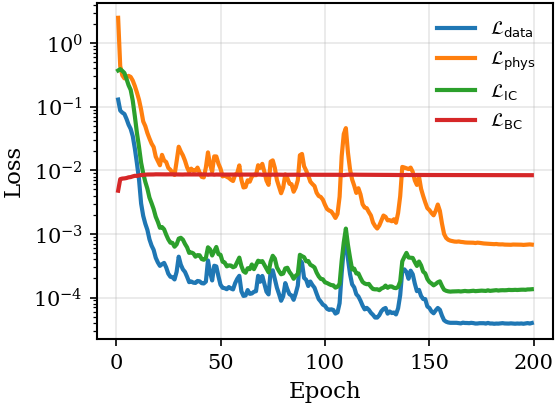

In [106]:
def plot_training_losses(history):
    epochs = np.arange(1, len(history["tot"]) + 1)

    plt.figure(figsize=(4.0, 3.0))

    plt.plot(epochs[0:199], history["data"][0:199], label=r"$\mathcal{L}_{\text{data}}$")
    plt.plot(epochs[0:199], history["phys"][0:199], label=r"$\mathcal{L}_{\text{phys}}$")
    plt.plot(epochs[0:199], history["ic"][0:199],   label=r"$\mathcal{L}_{\text{IC}}$")
    plt.plot(epochs[0:199], history["bc"][0:199],   label=r"$\mathcal{L}_{\text{BC}}$")

    plt.yscale("log")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    # plt.title("Training loss components")
    plt.grid(alpha=0.3, linewidth=0.8)
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


# Plot the different components on the same figure
plot_training_losses(history)

In [99]:
def plot_3x4_summary(x, t, X, T, kinds, pred_dict, ref_dict, nu):
    """
    3 x 4 figure:
      rows  = initial conditions
      cols:
        1) u(x,0)
        2) Exact solution
        3) FNO prediction
        4) Difference (pred - exact)
    """

    # Map kind -> label
    kind_label = {
        "sine":       "Single-Mode",
        "two_mode":   "Two-Mode",
        "three_mode": "Three-Mode",
    }

    nrows = len(kinds)
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(3.2*ncols, 2.4*nrows),
                             sharex=False, sharey=False)

    if nrows == 1:
        axes = np.array([axes])

    # ---------- Global color scale ----------
    all_true = np.concatenate([ref_dict[k].ravel() for k in kinds])
    all_pred = np.concatenate([pred_dict[k].ravel() for k in kinds])
    u_min = min(all_true.min(), all_pred.min())
    u_max = max(all_true.max(), all_pred.max())

    all_diff = np.concatenate([(pred_dict[k] - ref_dict[k]).ravel() for k in kinds])
    diff_max = np.max(np.abs(all_diff))

    extent = [x.min(), x.max(), t.min(), t.max()]

    # ---------- Column titles ----------
    col_titles = [
        r"$u(x,0)$",
        r"Exact : $u_{\mathrm{ref}}(x,t)$",
        r"FNO : $u_{\theta}(x,t)$",
        r"Error : $u_{\theta}-u_{\mathrm{ref}}$"
    ]
    for ci, title in enumerate(col_titles):
        axes[0, ci].set_title(title)

    # ---------- Fill the grid ----------
    for ri, kind in enumerate(kinds):

        u_ref  = ref_dict[kind]
        u_pred = pred_dict[kind]

        # (1) IC line plot
        ax_ic = axes[ri, 0]
        ax_ic.plot(x, u_ref[0], color="k")
        ax_ic.grid(alpha=0.3, linewidth=0.8)
        if ri == nrows - 1:
            ax_ic.set_xlabel(r"$x$")
        ax_ic.set_ylabel(kind_label[kind], fontsize=11)

        # (2) Exact solution
        ax_true = axes[ri, 1]
        im_true = ax_true.imshow(u_ref, aspect='auto', origin='lower',
                                 extent=extent, cmap="coolwarm",
                                 vmin=u_min, vmax=u_max)
        if ri == nrows - 1:
            ax_true.set_xlabel(r"$x$")
        ax_true.set_ylabel(r"$t$")
        fig.colorbar(im_true, ax=ax_true, fraction=0.046, pad=0.04)

        # (3) FNO prediction
        ax_pred = axes[ri, 2]
        im_pred = ax_pred.imshow(u_pred, aspect='auto', origin='lower',
                                 extent=extent, cmap="coolwarm",
                                 vmin=u_min, vmax=u_max)
        if ri == nrows - 1:
            ax_pred.set_xlabel(r"$x$")
        ax_pred.set_yticklabels([])
        fig.colorbar(im_pred, ax=ax_pred, fraction=0.046, pad=0.04)

        # (4) Difference
        diff = u_pred - u_ref
        ax_diff = axes[ri, 3]
        im_diff = ax_diff.imshow(diff, aspect='auto', origin='lower',
                                 extent=extent, cmap="bwr",
                                 vmin=-diff_max, vmax=diff_max)
        if ri == nrows - 1:
            ax_diff.set_xlabel(r"$x$")
        ax_diff.set_yticklabels([])
        fig.colorbar(im_diff, ax=ax_diff, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


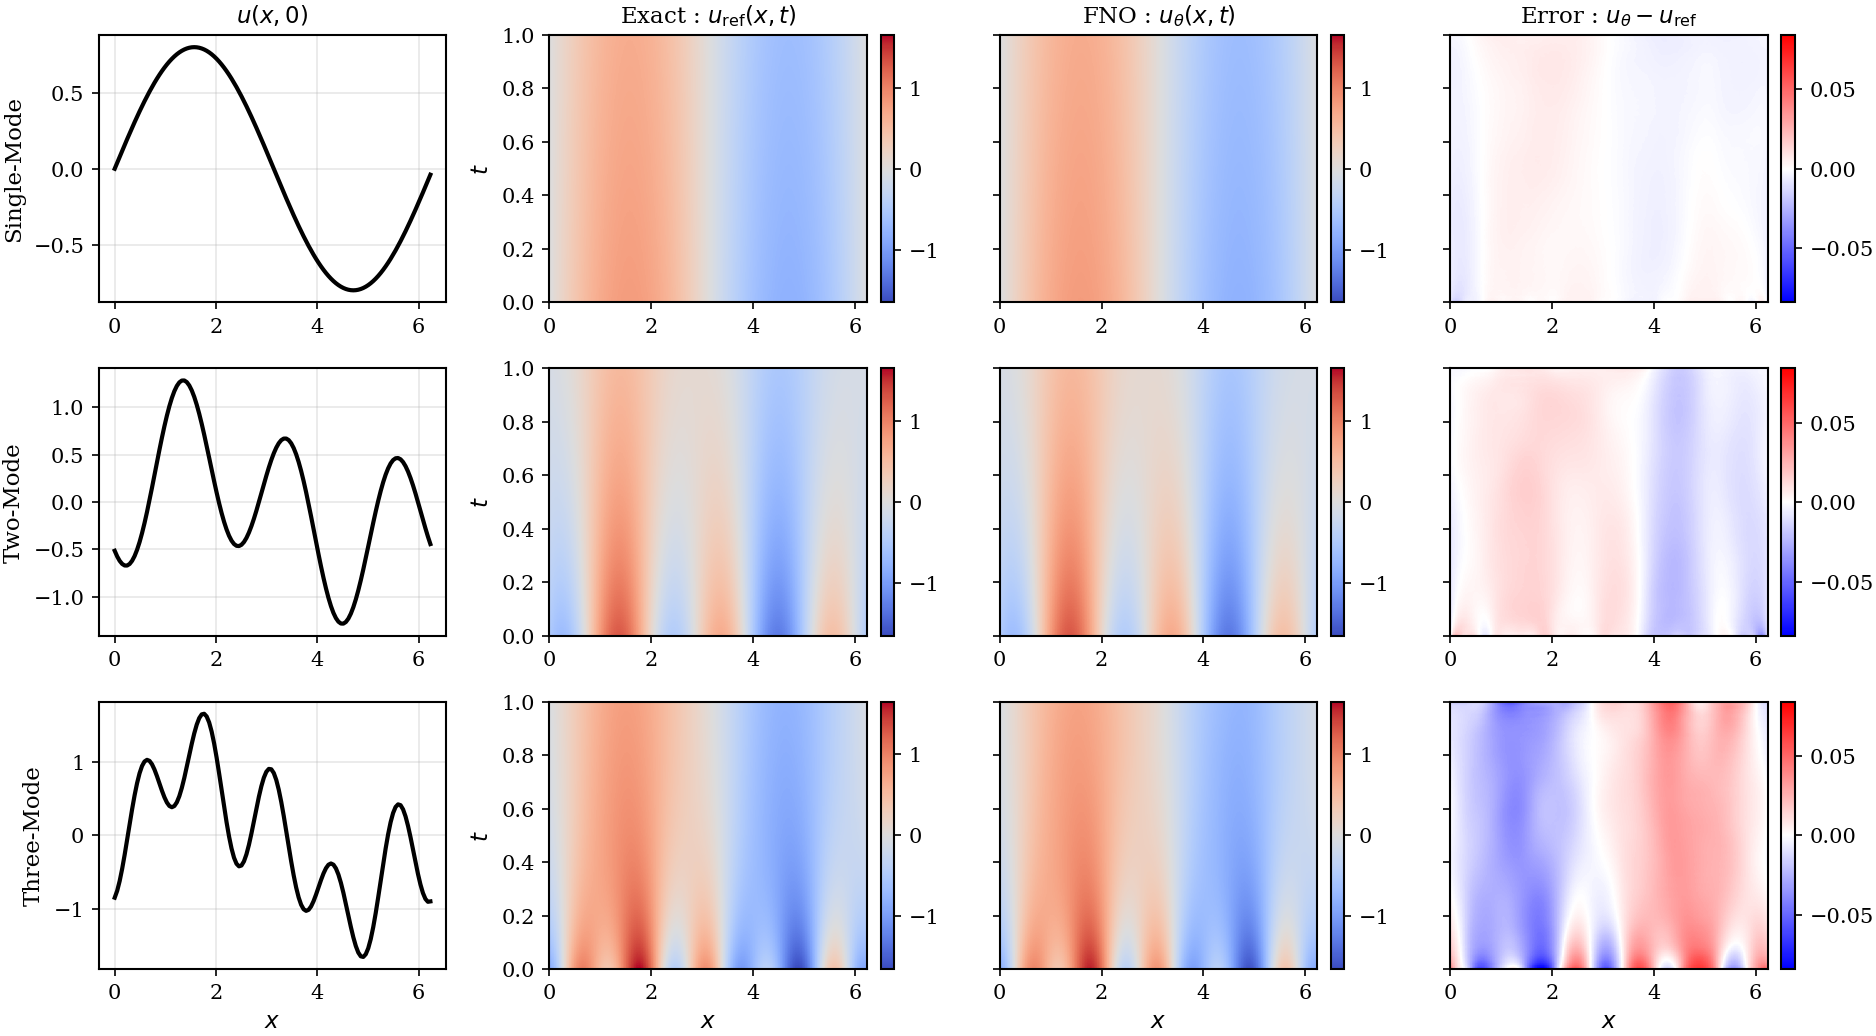

In [100]:
# After the loop over kinds where you filled pred_dict[kind] and ref_dict[kind]
plot_3x4_summary(x, t, X, T, kinds, pred_dict, ref_dict, nu)


In [103]:
def plot_time_slice_grid(x, t, kinds, pred_dict, ref_dict,
                         t_indices, t_labels):
    """
    Multi-panel figure:
      rows = time slices
      cols = IC types (Single-Mode / Two-Mode / Three-Mode)
      Each panel autos-scales its own ylim.
      Time labels (t = ...) appear in top-right.
    """

    kind_label = {
        "sine":       "Single-Mode",
        "two_mode":   "Two-Mode",
        "three_mode": "Three-Mode",
    }

    nrows = len(t_indices)
    ncols = len(kinds)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(3.0*ncols, 2.4*nrows),
        sharex=True,
        sharey=False
    )

    if nrows == 1:
        axes = np.array([axes])
    if ncols == 1:
        axes = axes[:, np.newaxis]

    # ---------- Column titles ----------
    for ci, kind in enumerate(kinds):
        axes[0, ci].set_title(kind_label.get(kind, kind))

    # ---------- Plotting ----------
    for ci, kind in enumerate(kinds):
        u_ref  = ref_dict[kind]
        u_pred = pred_dict[kind]

        for ri, (tidx, lbl_t) in enumerate(zip(t_indices, t_labels)):
            ax = axes[ri, ci]

            # Exact
            ax.plot(
                x, u_ref[tidx],
                linestyle="-",
                color="C0",
                linewidth=3.2,
                label = 'Exact'
            )

            # FNO
            ax.plot(
                x, u_pred[tidx],
                linestyle="--",
                color="C1",
                linewidth=3.0,
                label = 'FNO'
            )

            # x-label last row
            if ri == nrows - 1:
                ax.set_xlabel(r"$x$")

            # y-label first column
            if ci == 0:
                ax.set_ylabel(r"$u(x,t)$")

            # ---------- Time label moved to TOP-RIGHT ----------
            ax.text(
                0.98, 0.98,              # <--- position: top-right corner
                lbl_t,
                transform=ax.transAxes,
                fontsize=9,
                ha="right",
                va="top"
            )

            ax.grid(alpha=0.2, linewidth=0.8)

    # ---------- Global legend ----------
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels,
               loc="upper center", ncol=2,
               frameon=False,
               bbox_to_anchor=(0.5, 1.02))

    plt.tight_layout()
    plt.show()


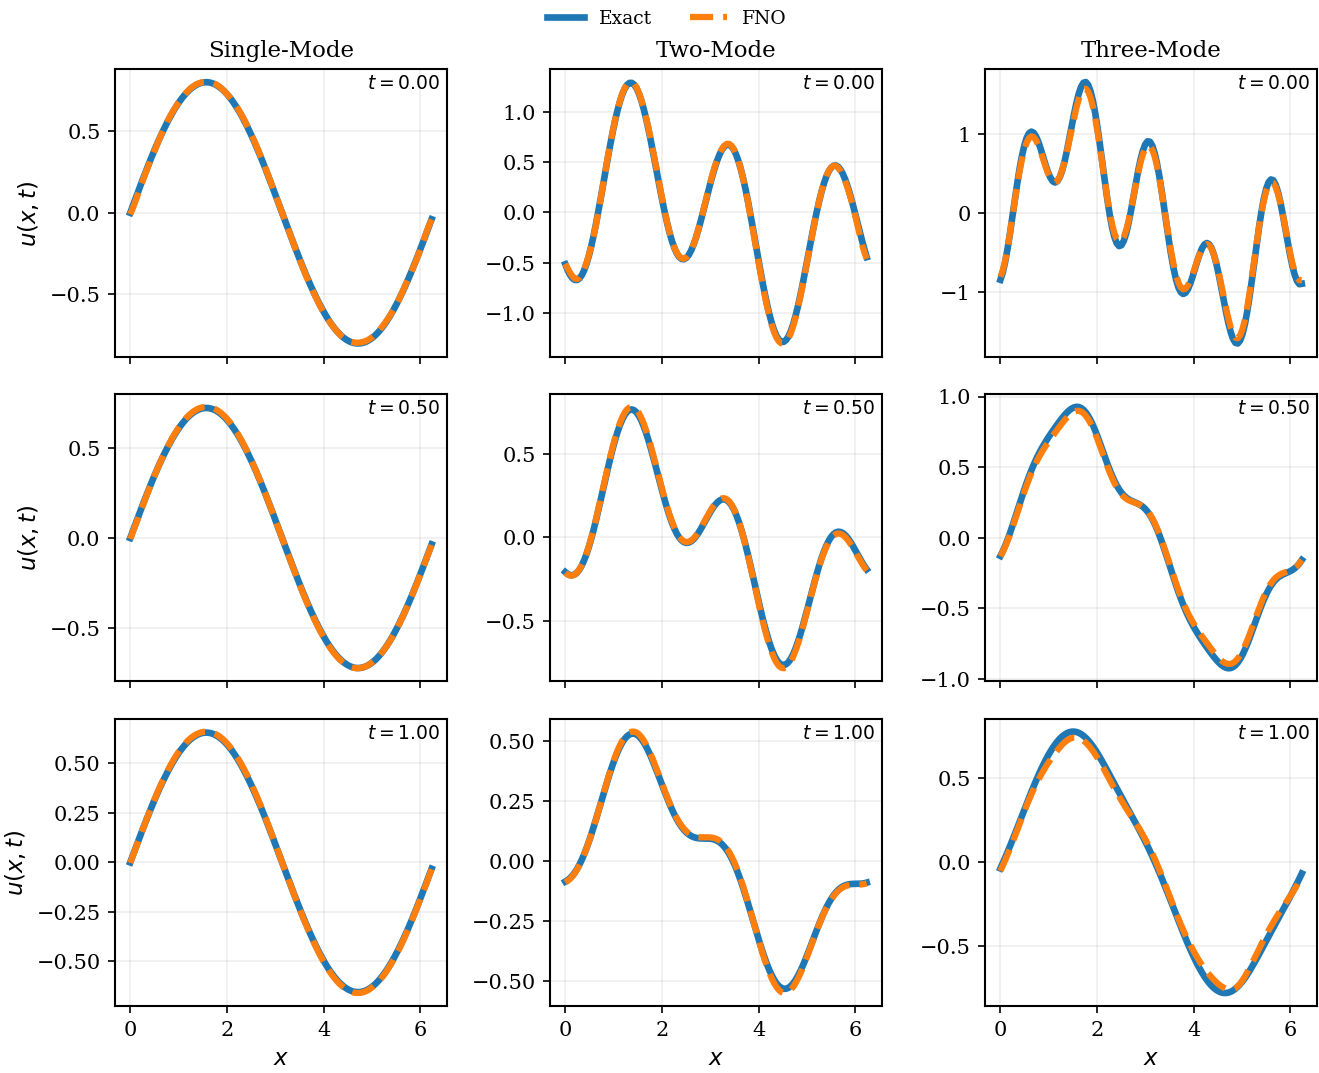

In [104]:
# Choose time indices for slice plots, including t ≈ 0.75
idx_0     = 0
idx_mid   = Nt // 2

t_target  = 0.75 * Tfinal       # here Tfinal = 1.0
idx_075   = int(np.argmin(np.abs(t - t_target)))
idx_final = Nt - 1

t_indices = [idx_0, idx_mid, idx_final]
t_labels  = [rf"$t = {t[idx_0]:.2f}$",
             rf"$t = {t[idx_mid]:.2f}$",
             rf"$t = {t[idx_final]:.2f}$"]

plot_time_slice_grid(x, t, kinds, pred_dict, ref_dict, t_indices, t_labels)

